In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;
import phi2D_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_10.0/DN_FLUXDRIVEN_ITG_TEST";
data_arrays = reader.fetch_phi2D_data(directory_path);

Found 1201 files in the directory. Beginning compilation...
Compiled data from 1000 files...
Finished compiling data from all files in the directory.


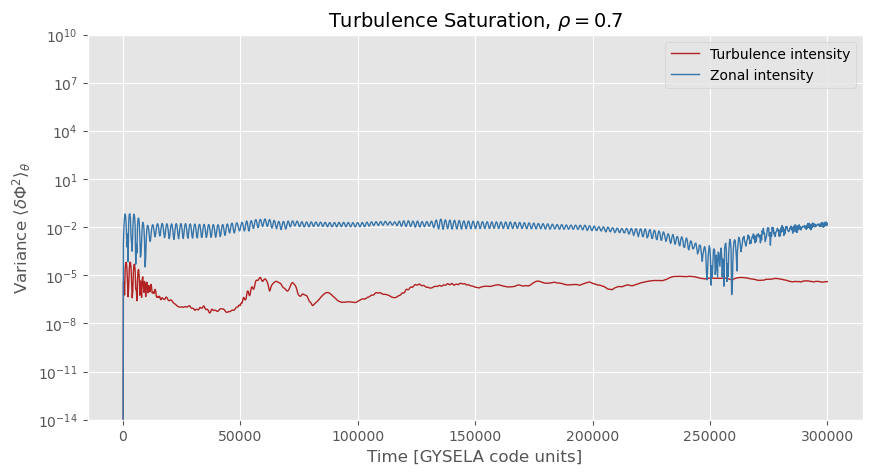

In [ ]:
def plot_turbulence_saturation(phi2D_list, dt_diag, effective_radius, log_scale = False):

	variance_series = utils.generate_turbulent_variance_time_series(phi2D_list, effective_radius);
	zonal_series = utils.generate_zonal_variance_time_series(phi2D_list, effective_radius);
	time_range = np.arange(len(variance_series)) * dt_diag;

	# Figure plotting logic.
	plt.figure(figsize = (10, 5));
	operation = plt.semilogy if log_scale else plt.plot;
	operation(time_range, variance_series, color = "firebrick", lw = 1.0, label = "Turbulence intensity");
	operation(time_range, zonal_series, color = "#3776ab", lw = 1.0, label = "Zonal intensity");
	plt.title(f"Turbulence Saturation, $\\rho = {effective_radius}$", fontsize = 14);
	plt.xlabel("Time [GYSELA code units]", fontsize = 12);
	plt.ylabel(r"Variance $\langle \delta \Phi^2 \rangle_\theta$", fontsize = 12);
	plt.ylim(10e-15, 10e9);
	plt.legend();
	plt.show();

plot_turbulence_saturation(data_arrays, dt_diag = 250, effective_radius = 0.7, log_scale = True);